<a href="https://colab.research.google.com/github/ilfpns/PhoSem/blob/main/Phosem_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os, glob, zipfile
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt

print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

PyTorch: 2.11.0+cu128
CUDA: True
Device: Tesla T4


In [50]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

!apt-get -qq install fonts-nanum > /dev/null

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

print("폰트 설정 완료:", plt.rcParams['font.family'])

폰트 설정 완료: ['NanumGothic']


In [31]:
import os
SRC = "/content/drive/MyDrive/all_data"
print(os.listdir(SRC)[:10])
print("총 항목 수:", len(os.listdir(SRC)))

import os, glob, shutil

SRC = "/content/drive/MyDrive/all_data"
DATA_DIR = "/content/dataset"

if os.path.exists(DATA_DIR):
    shutil.rmtree(DATA_DIR)
os.makedirs(DATA_DIR)

IMG_EXTS = (".png", ".jpg", ".jpeg", ".bmp")
copied, seen_names = 0, set()
for root, dirs, files in os.walk(SRC, followlinks=False):
    dirs[:] = [d for d in dirs if not os.path.islink(os.path.join(root, d))]
    for f in files:
        if f.lower().endswith(IMG_EXTS) and f not in seen_names:
            shutil.copy2(os.path.join(root, f), os.path.join(DATA_DIR, f))
            seen_names.add(f)
            copied += 1

print(f"복사 완료: {copied}장")

['all_data', '357-x.jpg', '323-x_die800.jpg', '513-x_die800.jpg', '287-o_die800.jpg', '482-x.jpg', '283-x.jpg', '481-x.jpg', '346-o_die800.jpg', '429-x_die800.jpg']
총 항목 수: 503
복사 완료: 502장


In [32]:
import os, glob, shutil

SRC = "/content/drive/MyDrive/all_data"
DATA_DIR = "/content/dataset"

if os.path.exists(DATA_DIR):
    shutil.rmtree(DATA_DIR)
os.makedirs(DATA_DIR)

IMG_EXTS = (".png", ".jpg", ".jpeg", ".bmp")

# 심볼릭 링크는 따라가지 않고, 실제 파일 목록만 os.walk로 수집
copied, seen_names = 0, set()
for root, dirs, files in os.walk(SRC, followlinks=False):
    # 링크로 만들어진 하위 디렉토리는 아예 내려가지 않도록 제거
    dirs[:] = [d for d in dirs if not os.path.islink(os.path.join(root, d))]
    for f in files:
        if f.lower().endswith(IMG_EXTS) and f not in seen_names:
            shutil.copy2(os.path.join(root, f), os.path.join(DATA_DIR, f))
            seen_names.add(f)
            copied += 1

print(f"복사 완료: {copied}장 (중복 이름 제외)")

복사 완료: 502장 (중복 이름 제외)


It appears the `data_loader` module is missing. This module is expected to be part of the `Phosem-CNN-Problem-Detection` project. I will clone the GitHub repository to ensure all necessary files are available.

In [28]:
import os

repo_path = "/content/Phosem-CNN-Problem-Detection"
if not os.path.exists(repo_path):
    !git clone https://github.com/Phosem/Phosem-CNN-Problem-Detection.git {repo_path}
    print(f"Repository cloned to {repo_path}")
else:
    print(f"Repository already exists at {repo_path}")

if os.path.exists(os.path.join(repo_path, 'data_loader.py')):
    print("data_loader.py found.")
else:
    print("Error: data_loader.py not found in the cloned repository.")

Repository already exists at /content/Phosem-CNN-Problem-Detection
data_loader.py found.


In [36]:
import re

def parse_filename(path):
    name = os.path.splitext(os.path.basename(path))[0].lower()
    m = re.match(r"^(\d+)[-_]([ox])(.*)$", name)
    if not m:
        return None
    num, ox, rest = m.groups()
    return {"path": path, "num": int(num),
            "label": "good" if ox == "o" else "bad",
            "is_die": "die" in rest}

all_files = sorted(p for p in glob.glob(os.path.join(DATA_DIR, "**", "*"), recursive=True)
                   if p.lower().endswith(IMG_EXTS))
parsed   = [info for p in all_files if (info := parse_filename(p))]
unparsed = [p for p in all_files if parse_filename(p) is None]
die_files = [f for f in parsed if f["is_die"]]
good_paths = sorted(f["path"] for f in die_files if f["label"] == "good")
bad_paths  = sorted(f["path"] for f in die_files if f["label"] == "bad")

print(f"전체 {len(all_files)}장 | die 사용 {len(die_files)}장 → 양품 {len(good_paths)} / 불량 {len(bad_paths)}")
print(f"제외: die 미포함 {len(parsed)-len(die_files)}장, 규칙 불일치 {len(unparsed)}장")
for p in unparsed[:10]:
    print("  [규칙 불일치]", os.path.basename(p))

전체 502장 | die 사용 250장 → 양품 117 / 불량 133
제외: die 미포함 250장, 규칙 불일치 2장
  [규칙 불일치] 445-0.jpg
  [규칙 불일치] 445-0_die800.jpg


In [34]:
import re

IMG_EXTS = (".png", ".jpg", ".jpeg", ".bmp")

def parse_filename(path):
    """
    '429-x_die800.png' → {'num': 429, 'label': 'bad', 'is_die': True}
    '431-o.png'        → {'num': 431, 'label': 'good', 'is_die': False}
    규칙에 안 맞으면 None
    """
    name = os.path.splitext(os.path.basename(path))[0].lower()
    m = re.match(r"^(\d+)[-_]([ox])(.*)$", name)
    if not m:
        return None
    num, ox, rest = m.groups()
    return {
        "path": path,
        "num": int(num),
        "label": "good" if ox == "o" else "bad",
        "is_die": "die" in rest,
    }

all_files = sorted(
    p for p in glob.glob(os.path.join(DATA_DIR, "**", "*"), recursive=True)
    if p.lower().endswith(IMG_EXTS)
)

parsed    = [info for p in all_files if (info := parse_filename(p))]
unparsed  = [p for p in all_files if parse_filename(p) is None]

die_files  = [f for f in parsed if f["is_die"]]
good_paths = sorted(f["path"] for f in die_files if f["label"] == "good")
bad_paths  = sorted(f["path"] for f in die_files if f["label"] == "bad")

print(f"전체 이미지        : {len(all_files)}장")
print(f"  ├ die 포함(사용) : {len(die_files)}장  →  양품 {len(good_paths)} / 불량 {len(bad_paths)}")
print(f"  ├ die 미포함(제외): {len(parsed) - len(die_files)}장")
print(f"  └ 규칙 불일치     : {len(unparsed)}장")

if unparsed:
    print("\n[확인 필요] 파일명 규칙에 안 맞는 파일:")
    for p in unparsed[:10]:
        print("   ", os.path.basename(p))

assert good_paths, "양품(die) 이미지가 없습니다 — PatchCore 메모리 뱅크에 필수"
print("\n양품 예시:", [os.path.basename(p) for p in good_paths[:3]])
print("불량 예시:", [os.path.basename(p) for p in bad_paths[:3]])

전체 이미지        : 502장
  ├ die 포함(사용) : 250장  →  양품 117 / 불량 133
  ├ die 미포함(제외): 250장
  └ 규칙 불일치     : 2장

[확인 필요] 파일명 규칙에 안 맞는 파일:
    445-0.jpg
    445-0_die800.jpg

양품 예시: ['278-o_die800.jpg', '279-o_die800.jpg', '280-o_die800.jpg']
불량 예시: ['276-x_die800.jpg', '277-x_die800.jpg', '283-x_die800.jpg']


/tmp/ipykernel_378/2314251731.py:19: UserWarning: Glyph 50577 (\N{HANGUL SYLLABLE YANG}) missing from font(s) DejaVu Sans.
  fig.suptitle(title); plt.tight_layout(); plt.show()
/tmp/ipykernel_378/2314251731.py:19: UserWarning: Glyph 54408 (\N{HANGUL SYLLABLE PUM}) missing from font(s) DejaVu Sans.
  fig.suptitle(title); plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50577 (\N{HANGUL SYLLABLE YANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54408 (\N{HANGUL SYLLABLE PUM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


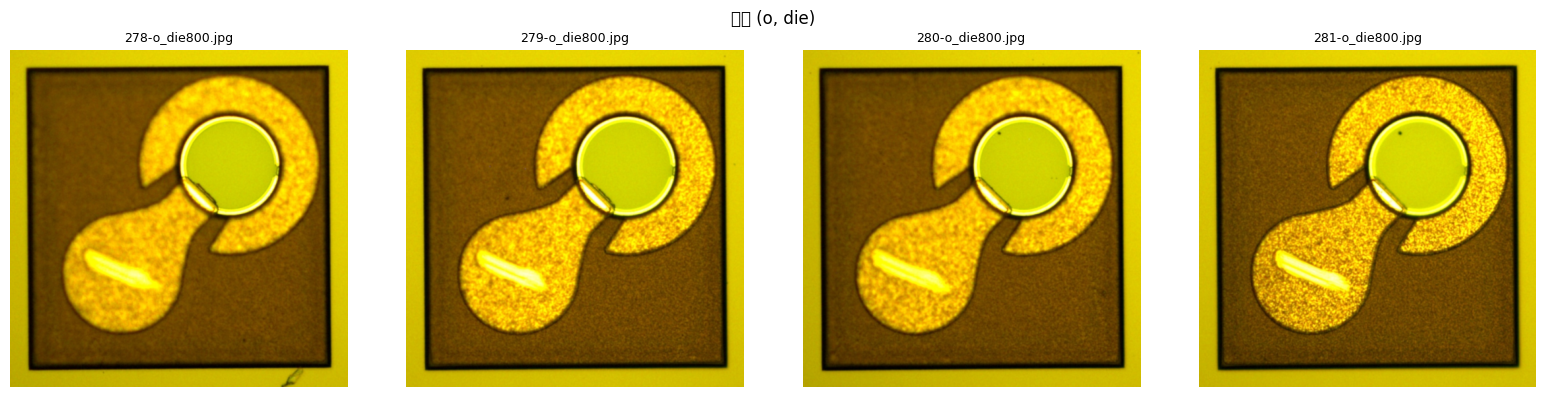

/tmp/ipykernel_378/2314251731.py:19: UserWarning: Glyph 48520 (\N{HANGUL SYLLABLE BUL}) missing from font(s) DejaVu Sans.
  fig.suptitle(title); plt.tight_layout(); plt.show()
/tmp/ipykernel_378/2314251731.py:19: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  fig.suptitle(title); plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48520 (\N{HANGUL SYLLABLE BUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


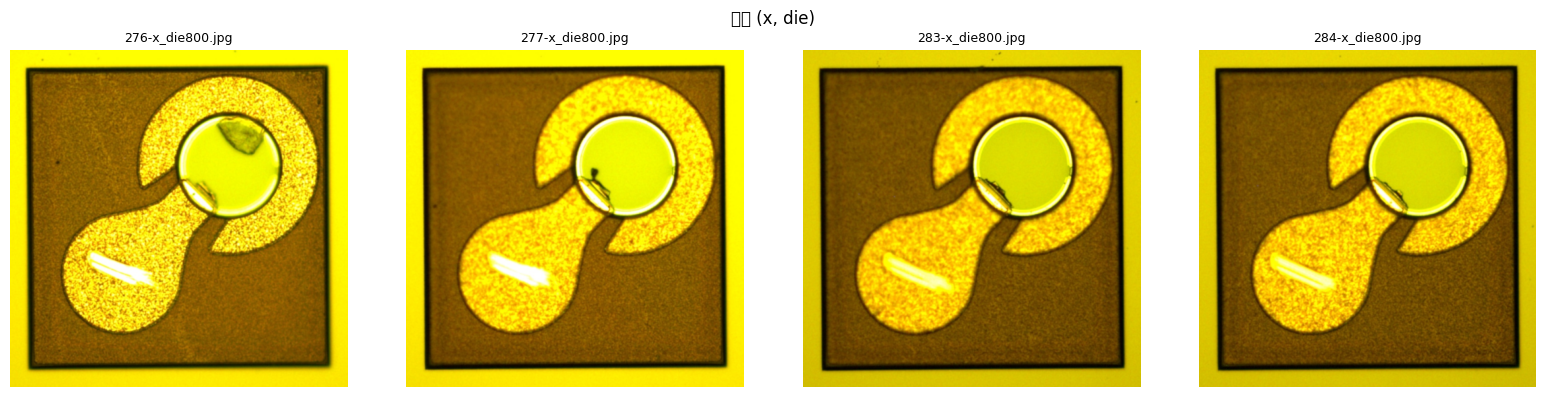

In [37]:
import sys, importlib
import matplotlib.pyplot as plt
import os

sys.path.insert(0, "/content/Phosem-CNN-Problem-Detection")
importlib.invalidate_caches()
from data_loader import load_image_gpu, load_batch_gpu, scan_dataset

def show_row(paths, title, n=4):
    n = min(n, len(paths))
    if n == 0:
        print(f"{title}: 없음"); return
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    axes = [axes] if n == 1 else axes
    for ax, p in zip(axes, paths[:n]):
        t, _ = load_image_gpu(p)
        ax.imshow(t[0].permute(1, 2, 0).cpu().numpy())
        ax.set_title(os.path.basename(p), fontsize=9); ax.axis("off")
    fig.suptitle(title); plt.tight_layout(); plt.show()

show_row(good_paths, "양품 (o, die)")
show_row(bad_paths,  "불량 (x, die)")

In [38]:
import random
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from PIL import Image

IMG_SIZE = 256
class DieDataset(Dataset):
    def __init__(self, paths, labels, train=True):
        self.paths, self.labels = paths, labels
        if train:
            self.tf = T.Compose([
                T.Resize((IMG_SIZE, IMG_SIZE)),
                T.RandomHorizontalFlip(),
                T.RandomVerticalFlip(),
                T.RandomRotation(10),
                T.ColorJitter(brightness=0.2, contrast=0.2),
                T.ToTensor(),
            ])
        else:
            self.tf = T.Compose([T.Resize((IMG_SIZE, IMG_SIZE)), T.ToTensor()])

    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert("RGB")
        return self.tf(img), self.labels[i]

all_paths  = good_paths + bad_paths
all_labels = [0]*len(good_paths) + [1]*len(bad_paths)

idx = list(range(len(all_paths)))
random.seed(42); random.shuffle(idx)
split = int(len(idx)*0.8)
tr_idx, va_idx = idx[:split], idx[split:]

train_ds = DieDataset([all_paths[i] for i in tr_idx], [all_labels[i] for i in tr_idx], train=True)
val_ds   = DieDataset([all_paths[i] for i in va_idx], [all_labels[i] for i in va_idx], train=False)
train_dl = DataLoader(train_ds, batch_size=8, shuffle=True)
val_dl   = DataLoader(val_ds, batch_size=8)

print(f"학습 {len(train_ds)}장 / 검증 {len(val_ds)}장")
print(f"검증 세트 불량 비율: {sum(all_labels[i] for i in va_idx)}/{len(va_idx)}")

학습 200장 / 검증 50장
검증 세트 불량 비율: 26/50


In [40]:
import torch
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [41]:
import torch.nn as nn

def build_cnn(channels=[16, 32, 64], num_classes=2, in_size=IMG_SIZE):
    """channels 리스트 = 각 conv층 채널 수. 리스트 길이 = 층수(깊이)"""
    layers, in_ch = [], 3
    for out_ch in channels:
        layers += [
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        ]
        in_ch = out_ch
    layers += [nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(in_ch, num_classes)]
    return nn.Sequential(*layers)

model = build_cnn([16, 32, 64, 128]).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"파라미터 수: {n_params:,}")

Sequential(
  (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU(inplace=True)
  (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): ReLU(inplace=True)
  (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (12): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (14): ReLU(inplac

In [42]:
def train_model(model, train_dl, val_dl, epochs=30, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    best_acc, history = 0, []

    for ep in range(1, epochs+1):
        model.train(); tr_loss = 0
        for x, y in train_dl:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(x), y)
            loss.backward(); opt.step()
            tr_loss += loss.item() * len(x)

        # 검증
        model.eval(); correct = total = 0
        with torch.no_grad():
            for x, y in val_dl:
                x, y = x.to(DEVICE), y.to(DEVICE)
                correct += (model(x).argmax(1) == y).sum().item()
                total += len(x)
        acc = correct / total
        history.append((tr_loss/len(train_dl.dataset), acc))
        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), "best_classifier.pth")
        print(f"epoch {ep:2d} | loss {history[-1][0]:.4f} | val acc {acc:.3f}"
              + (" *" if acc == best_acc else ""))

    print(f"\n최고 검증 정확도: {best_acc:.3f} → best_classifier.pth 저장됨")
    return history

history = train_model(model, train_dl, val_dl)

epoch  1 | loss 0.7346 | val acc 0.520 *
epoch  2 | loss 0.7054 | val acc 0.520 *
epoch  3 | loss 0.6887 | val acc 0.560 *
epoch  4 | loss 0.6900 | val acc 0.600 *
epoch  5 | loss 0.6899 | val acc 0.560
epoch  6 | loss 0.6973 | val acc 0.540
epoch  7 | loss 0.6932 | val acc 0.460
epoch  8 | loss 0.6832 | val acc 0.580
epoch  9 | loss 0.6832 | val acc 0.540
epoch 10 | loss 0.6844 | val acc 0.620 *
epoch 11 | loss 0.6746 | val acc 0.480
epoch 12 | loss 0.6926 | val acc 0.520
epoch 13 | loss 0.6916 | val acc 0.560
epoch 14 | loss 0.6650 | val acc 0.520
epoch 15 | loss 0.6924 | val acc 0.620 *
epoch 16 | loss 0.6706 | val acc 0.640 *
epoch 17 | loss 0.6796 | val acc 0.520
epoch 18 | loss 0.6776 | val acc 0.620
epoch 19 | loss 0.6745 | val acc 0.540
epoch 20 | loss 0.6877 | val acc 0.540
epoch 21 | loss 0.6821 | val acc 0.680 *
epoch 22 | loss 0.6910 | val acc 0.500
epoch 23 | loss 0.6780 | val acc 0.520
epoch 24 | loss 0.6725 | val acc 0.520
epoch 25 | loss 0.6820 | val acc 0.680 *
epoch 2

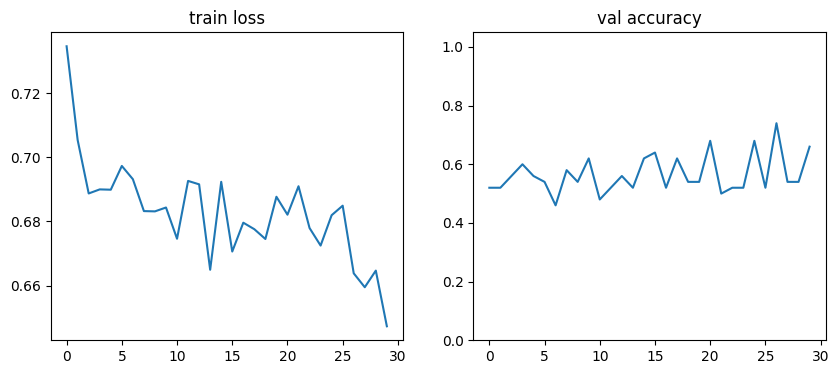

파일                                       정답   예측   불량확률
506-x_die800.jpg                         불량   불량   0.56
536-o_die800.jpg                         양품   양품   0.49
442-x_die800.jpg                         불량   불량   0.51
484-x_die800.jpg                         불량   불량   0.55
402-o_die800.jpg                         양품   양품   0.48
469-x_die800.jpg                         불량   불량   0.53
537-o_die800.jpg                         양품   양품   0.48
488-x_die800.jpg                         불량   양품   0.48  ← 오답
411-x_die800.jpg                         불량   불량   0.50
404-o_die800.jpg                         양품   양품   0.50
461-x_die800.jpg                         불량   양품   0.47  ← 오답
441-x_die800.jpg                         불량   불량   0.52
279-o_die800.jpg                         양품   양품   0.47
462-x_die800.jpg                         불량   양품   0.48  ← 오답
521-o_die800.jpg                         양품   양품   0.49
335-x_die800.jpg                         불량   불량   0.54
564-o_die800.jpg              

In [43]:
losses, accs = zip(*history)
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(losses); ax[0].set_title("train loss")
ax[1].plot(accs); ax[1].set_title("val accuracy"); ax[1].set_ylim(0, 1.05)
plt.show()

# 검증 이미지별 판정 결과
model.load_state_dict(torch.load("best_classifier.pth"))
model.eval()
print(f"{'파일':40s} 정답   예측   불량확률")
with torch.no_grad():
    for i in va_idx:
        x = val_ds.tf(Image.open(all_paths[i]).convert("RGB")).unsqueeze(0).to(DEVICE)
        prob = torch.softmax(model(x), 1)[0, 1].item()
        gt, pred = ["양품","불량"][all_labels[i]], ["양품","불량"][prob > 0.5]
        mark = "" if gt == pred else "  ← 오답"
        print(f"{os.path.basename(all_paths[i]):40s} {gt}   {pred}   {prob:.2f}{mark}")

In [44]:
import pandas as pd
import numpy as np

model.load_state_dict(torch.load("best_classifier.pth"))
model.eval()

rows = []
with torch.no_grad():
    for i in va_idx:
        x = val_ds.tf(Image.open(all_paths[i]).convert("RGB")).unsqueeze(0).to(DEVICE)
        prob = torch.softmax(model(x), 1)[0, 1].item()
        rows.append({
            "파일": os.path.basename(all_paths[i]),
            "정답": ["양품", "불량"][all_labels[i]],
            "예측": ["양품", "불량"][int(prob > 0.5)],
            "불량확률": round(prob, 3),
            "판정": "O" if (prob > 0.5) == bool(all_labels[i]) else "X",
        })

df = pd.DataFrame(rows).sort_values("불량확률", ascending=False).reset_index(drop=True)
display(df)

cm = pd.crosstab(df["정답"], df["예측"], rownames=["정답"], colnames=["예측"])
display(cm)

tp = len(df[(df.정답=="불량") & (df.예측=="불량")])
fn = len(df[(df.정답=="불량") & (df.예측=="양품")])
fp = len(df[(df.정답=="양품") & (df.예측=="불량")])
tn = len(df[(df.정답=="양품") & (df.예측=="양품")])

summary = pd.DataFrame({
    "지표": ["정확도", "불량 검출률 (recall)", "불량 예측 정밀도 (precision)", "과검률 (양품→불량 오판)"],
    "값": [
        f"{(tp+tn)/len(df):.1%}",
        f"{tp/(tp+fn):.1%}" if tp+fn else "-",
        f"{tp/(tp+fp):.1%}" if tp+fp else "-",
        f"{fp/(fp+tn):.1%}" if fp+tn else "-",
    ],
})
display(summary)

,파일,정답,예측,불량확률,판정
0,416-x_die800.jpg,불량,불량,0.701,O
1,564-o_die800.jpg,양품,불량,0.595,X
2,336-o_die800.jpg,양품,불량,0.583,X
3,412-x_die800.jpg,불량,불량,0.579,O
4,483-x_die800.jpg,불량,불량,0.570,O
5,506-x_die800.jpg,불량,불량,0.563,O
6,360-o_die800.jpg,양품,불량,0.557,X
7,484-x_die800.jpg,불량,불량,0.546,O
8,493-o_die800.jpg,양품,불량,0.542,X
9,335-x_die800.jpg,불량,불량,0.537,O


예측,불량,양품
정답,,
불량,22,4
양품,9,15


,지표,값
0,정확도,74.0%
1,불량 검출률 (recall),84.6%
2,불량 예측 정밀도 (precision),71.0%
3,과검률 (양품→불량 오판),37.5%


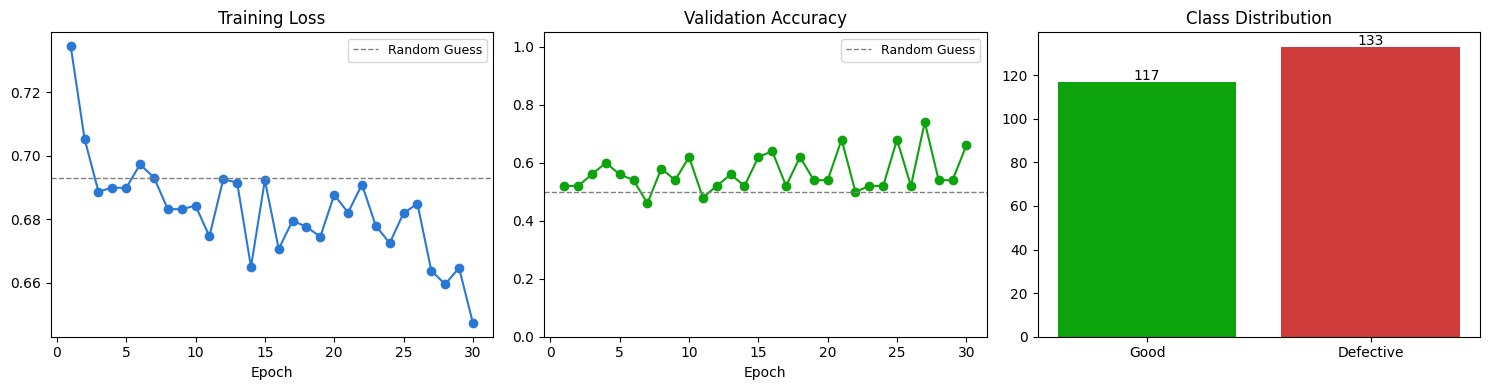

Final Epoch: Loss 0.6473 | Validation Accuracy 0.660
Best Validation Accuracy: 0.740 (Epoch 27)
Class Ratio: Good 117 : Defective 133 (Ratio 0.88:1)


In [48]:
import matplotlib.pyplot as plt

assert 'history' in globals(), "history not found — run the training cell (train_model) first."
assert 'good_paths' in globals() and 'bad_paths' in globals(), \
    "good_paths/bad_paths not found — run the dataset scanning cell first."

losses, accs = zip(*history)
epochs = list(range(1, len(history) + 1))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs, losses, marker='o', color='#2a78d6')
axes[0].axhline(0.693, color='gray', linestyle='--', linewidth=1, label='Random Guess')
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend(fontsize=9)

axes[1].plot(epochs, accs, marker='o', color='#0ca30c')
axes[1].axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Random Guess')
axes[1].set_ylim(0, 1.05)
axes[1].set_title("Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend(fontsize=9)

counts = [len(good_paths), len(bad_paths)]
bars = axes[2].bar(["Good", "Defective"], counts, color=["#0ca30c", "#d03b3b"])
axes[2].set_title("Class Distribution")
for b, c in zip(bars, counts):
    axes[2].text(b.get_x() + b.get_width()/2, c + 1, str(c), ha='center')

plt.tight_layout()
plt.show()

print(f"Final Epoch: Loss {losses[-1]:.4f} | Validation Accuracy {accs[-1]:.3f}")
print(f"Best Validation Accuracy: {max(accs):.3f} (Epoch {accs.index(max(accs)) + 1})")
print(
    f"Class Ratio: Good {counts[0]} : Defective {counts[1]} "
    f"(Ratio {counts[0] / counts[1]:.2f}:1)"
    if counts[1]
    else "No defective samples."
)

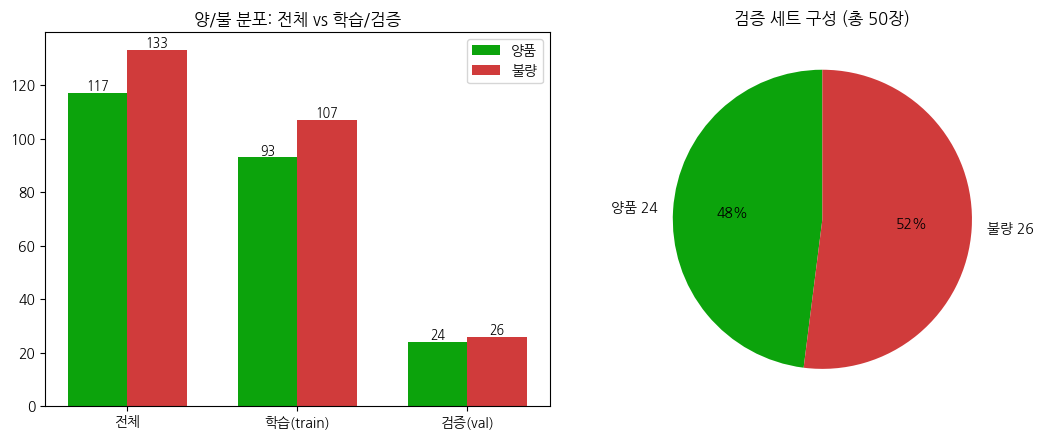

전체: 양품 117 / 불량 133  (비율 0.88:1)
학습: 양품 93 / 불량 107
검증: 양품 24 / 불량 26


In [51]:
import matplotlib.pyplot as plt
import numpy as np

assert 'all_labels' in globals() and 'tr_idx' in globals() and 'va_idx' in globals(), \
    "all_labels/tr_idx/va_idx 없음 — 데이터셋 분할 셀 먼저 실행"

train_labels = [all_labels[i] for i in tr_idx]
val_labels = [all_labels[i] for i in va_idx]
train_good, train_bad = train_labels.count(0), train_labels.count(1)
val_good, val_bad = val_labels.count(0), val_labels.count(1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

x = np.arange(3)
width = 0.35
good_counts = [len(good_paths), train_good, val_good]
bad_counts = [len(bad_paths), train_bad, val_bad]

axes[0].bar(x - width/2, good_counts, width, label='양품', color='#0ca30c')
axes[0].bar(x + width/2, bad_counts, width, label='불량', color='#d03b3b')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['전체', '학습(train)', '검증(val)'])
axes[0].set_title("양/불 분포: 전체 vs 학습/검증")
axes[0].legend()
for i, (g, b) in enumerate(zip(good_counts, bad_counts)):
    axes[0].text(i - width/2, g + 1, str(g), ha='center', fontsize=9)
    axes[0].text(i + width/2, b + 1, str(b), ha='center', fontsize=9)

axes[1].pie([val_good, val_bad], labels=[f'양품 {val_good}', f'불량 {val_bad}'],
            colors=['#0ca30c', '#d03b3b'], autopct='%1.0f%%', startangle=90)
axes[1].set_title(f"검증 세트 구성 (총 {len(val_labels)}장)")

plt.tight_layout()
plt.show()

print(f"전체: 양품 {len(good_paths)} / 불량 {len(bad_paths)}  (비율 {len(good_paths)/max(len(bad_paths),1):.2f}:1)")
print(f"학습: 양품 {train_good} / 불량 {train_bad}")
print(f"검증: 양품 {val_good} / 불량 {val_bad}")

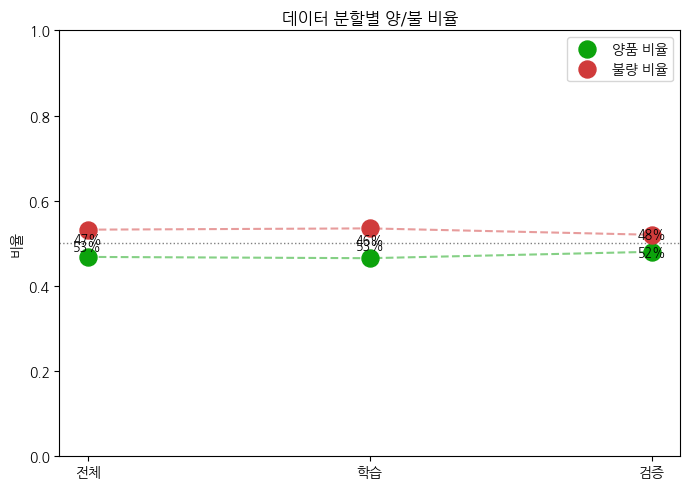

In [52]:
import matplotlib.pyplot as plt
import numpy as np

assert 'all_labels' in globals() and 'tr_idx' in globals() and 'va_idx' in globals(), "먼저 분할 셀 실행"

train_labels = [all_labels[i] for i in tr_idx]
val_labels = [all_labels[i] for i in va_idx]

splits = ['전체', '학습', '검증']
good_ratio = [
    len(good_paths) / (len(good_paths) + len(bad_paths)),
    train_labels.count(0) / len(train_labels),
    val_labels.count(0) / len(val_labels),
]
bad_ratio = [1 - g for g in good_ratio]
x = np.arange(len(splits))

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(x, good_ratio, color='#0ca30c', linestyle='--', alpha=0.5)
ax.scatter(x, good_ratio, s=150, color='#0ca30c', label='양품 비율', zorder=3)
ax.plot(x, bad_ratio, color='#d03b3b', linestyle='--', alpha=0.5)
ax.scatter(x, bad_ratio, s=150, color='#d03b3b', label='불량 비율', zorder=3)
ax.axhline(0.5, color='gray', linestyle=':', linewidth=1)

ax.set_xticks(x)
ax.set_xticklabels(splits)
ax.set_ylim(0, 1)
ax.set_ylabel('비율')
ax.set_title('데이터 분할별 양/불 비율')
ax.legend()

for i, (g, b) in enumerate(zip(good_ratio, bad_ratio)):
    ax.annotate(f'{g:.0%}', (x[i], g), textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9)
    ax.annotate(f'{b:.0%}', (x[i], b), textcoords="offset points", xytext=(0, -15), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [53]:
def find_recall_threshold(model, val_dl, target_recall=1.0):
    model.eval()
    probs, labels = [], []
    with torch.no_grad():
        for x, y in val_dl:
            p = torch.softmax(model(x.to(DEVICE)), 1)[:, 1].cpu()
            probs.extend(p.tolist()); labels.extend(y.tolist())
    probs, labels = np.array(probs), np.array(labels)

    rows = []
    for th in np.arange(0.05, 0.55, 0.05):
        pred = (probs > th).astype(int)
        tp = ((pred==1)&(labels==1)).sum(); fn = ((pred==0)&(labels==1)).sum()
        fp = ((pred==1)&(labels==0)).sum(); tn = ((pred==0)&(labels==0)).sum()
        recall = tp/(tp+fn) if tp+fn else 0
        rows.append({"threshold": round(th,2), "불량_recall": round(recall,3),
                     "놓친_불량": fn, "과검_양품": fp})
    df = pd.DataFrame(rows)
    display(df)
    ok = df[df.불량_recall >= target_recall]
    if len(ok):
        best = ok.iloc[ok.과검_양품.argmin()]
        print(f"\nrecall {target_recall} 달성하는 최고 threshold: {best.threshold} (과검 {best.과검_양품}건)")
    else:
        print(f"\n어떤 threshold로도 recall {target_recall} 달성 불가 — 모델 자체를 더 학습/개선 필요")
    return df

find_recall_threshold(model, val_dl, target_recall=1.0)

,threshold,불량_recall,놓친_불량,과검_양품
0,0.05,1.000,0,24
1,0.10,1.000,0,24
2,0.15,1.000,0,24
3,0.20,1.000,0,24
4,0.25,1.000,0,24
5,0.30,1.000,0,24
6,0.35,1.000,0,24
7,0.40,1.000,0,24
8,0.45,1.000,0,21
9,0.50,0.846,4,9



recall 1.0 달성하는 최고 threshold: 0.45 (과검 21.0건)


,threshold,불량_recall,놓친_불량,과검_양품
0,0.05,1.000,0,24
1,0.10,1.000,0,24
2,0.15,1.000,0,24
3,0.20,1.000,0,24
4,0.25,1.000,0,24
5,0.30,1.000,0,24
6,0.35,1.000,0,24
7,0.40,1.000,0,24
8,0.45,1.000,0,21
9,0.50,0.846,4,9


In [57]:
PER_IMAGE_SAMPLE = 800
CORESET_TARGET = 10000

raw_patches = []
batch_size = 4
for i in range(0, len(good_paths), batch_size):
    batch = good_paths[i:i+batch_size]
    imgs = torch.cat([load_for_patchcore(p)[0] for p in batch], dim=0)
    feats = extractor(imgs)
    B, C, H, W = feats.shape
    feats = feats.permute(0, 2, 3, 1).reshape(B, H*W, C)
    for b in range(B):
        idx = torch.randperm(H*W)[:PER_IMAGE_SAMPLE]
        raw_patches.append(feats[b, idx].cpu())
    if (i // batch_size) % 20 == 0:
        print(f"{min(i+batch_size, len(good_paths))}/{len(good_paths)}장")

raw_patches = torch.cat(raw_patches, dim=0)
print(f"수집된 패치: {raw_patches.shape[0]:,}개")

def greedy_coreset(features, n_select, device=DEVICE):
    features = features.to(device)
    N = features.shape[0]
    n_select = min(n_select, N)
    selected = [np.random.randint(N)]
    min_dists = torch.cdist(features, features[selected[-1]:selected[-1]+1]).squeeze(1)
    for step in range(1, n_select):
        idx = torch.argmax(min_dists).item()
        selected.append(idx)
        new_dists = torch.cdist(features, features[idx:idx+1]).squeeze(1)
        min_dists = torch.minimum(min_dists, new_dists)
        if step % 2000 == 0:
            print(f"coreset {step}/{n_select}")
    return features[selected]

memory_bank = greedy_coreset(raw_patches, CORESET_TARGET)
print(f"메모리 뱅크: {tuple(memory_bank.shape)}")

memory_bank = raw_patches.to(DEVICE)
print(f"메모리 뱅크(coreset 생략): {tuple(memory_bank.shape)}")

4/117장
84/117장
수집된 패치: 93,600개
coreset 2000/10000
coreset 4000/10000
coreset 6000/10000
coreset 8000/10000
메모리 뱅크: (10000, 1536)


In [58]:
import pandas as pd
import numpy as np

assert 'memory_bank' in globals()

results = []
for label, paths in [('양품', good_paths), ('불량', bad_paths)]:
    for p in paths:
        _, score, _ = patchcore_score(p, memory_bank, extractor)
        results.append({'파일': os.path.basename(p), '실제': label, '이상점수': score})

df = pd.DataFrame(results).sort_values('이상점수', ascending=False).reset_index(drop=True)
display(df)

def sweep_threshold(df, n=50):
    ths = np.linspace(df.이상점수.min(), df.이상점수.max(), n)
    rows = []
    for th in ths:
        pred_bad = df.이상점수 > th
        actual_bad = df.실제 == '불량'
        tp = (pred_bad & actual_bad).sum(); fn = (~pred_bad & actual_bad).sum()
        fp = (pred_bad & ~actual_bad).sum(); tn = (~pred_bad & ~actual_bad).sum()
        rows.append({'threshold': round(th,2), 'accuracy': round((tp+tn)/len(df),3),
                     '불량_recall': round(tp/(tp+fn),3) if tp+fn else 0,
                     '놓친_불량': fn, '과검_양품': fp})
    return pd.DataFrame(rows)

sweep = sweep_threshold(df)
display(sweep.sort_values('accuracy', ascending=False).head(10))
print(f"\n최고 accuracy: {sweep.accuracy.max():.1%}")

,파일,실제,이상점수
0,412-x_die800.jpg,불량,3.831978
1,477-x_die800.jpg,불량,3.615424
2,474-x_die800.jpg,불량,3.590183
3,441-x_die800.jpg,불량,3.586838
4,473-x_die800.jpg,불량,3.584779
...,...,...,...
245,557-o_die800.jpg,양품,1.638318
246,565-o_die800.jpg,양품,1.637109
247,522-o_die800.jpg,양품,1.622229
248,524-o_die800.jpg,양품,1.617117


,threshold,accuracy,불량_recall,놓친_불량,과검_양품
10,2.06,0.784,0.774,30,24
8,1.97,0.780,0.872,17,38
9,2.02,0.768,0.820,24,34
11,2.11,0.764,0.707,39,20
7,1.93,0.760,0.917,11,49
6,1.88,0.756,0.955,6,55
5,1.84,0.748,0.992,1,62
12,2.16,0.740,0.632,49,16
13,2.20,0.724,0.571,57,12
14,2.25,0.720,0.541,61,9



최고 accuracy: 78.4%
